In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

df = pd.read_csv('SuperMarket Analysis.csv')

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [2]:
df_S = df.copy()

# parsing Date and time, then creating a Datetime column

df_S['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'].astype(str), format='%m/%d/%Y %I:%M:%S %p')
df_S.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Datetime
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00


In [3]:
# Parsing the Date and Time seperately
df_S['Parsed_Date'] = pd.to_datetime(df_S.Date, format= "%m/%d/%Y", errors='coerce')

In [4]:
df_S['Parsed_Time'] = pd.to_datetime(df_S.Time, format="%I:%M:%S %p", errors='coerce').dt.time

df_S.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   object        
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [5]:
# Check nulls only for 'Parsed_Time' and 'Parsed_Date'
df_S[['Parsed_Time', 'Parsed_Date']].isnull().sum()

Parsed_Time    0
Parsed_Date    0
dtype: int64

Checking for Duplicates

In [6]:
dups = df_S.duplicated().sum()
print(f"Number of duplicate rows: {dups}")

Number of duplicate rows: 0


Statistics

In [7]:
df_S.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating,Datetime,Parsed_Date
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000,1000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270,2019-02-14 15:30:27.480000,2019-02-14 00:05:45.600000
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000,2019-01-01 10:39:00,2019-01-01 00:00:00
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000,2019-01-24 17:58:45,2019-01-24 00:00:00
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000,2019-02-13 17:37:00,2019-02-13 00:00:00
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000,2019-03-08 15:29:30,2019-03-08 00:00:00
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000,2019-03-30 20:37:00,2019-03-30 00:00:00
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858,NaN,NaN


Quality Check - If the Sales match the Unit Price * Quantity * 1.05 Tax rate

In [8]:
df_S['Expected_Sales'] = df_S['Unit price'] * df_S['Quantity'] * 1.05

# Compare with actual values
df_S['Sales_Match'] = np.isclose(df_S['Sales'], df_S['Expected_Sales'], rtol=1e-6)

# Check results
print(f"Total rows: {len(df_S)}")
print(f"Rows where Sales matches calculation: {df_S['Sales_Match'].sum()}")
print(f"Rows where Sales DOES NOT match: {(~df_S['Sales_Match']).sum()}")
print(f"Match percentage: {(df_S['Sales_Match'].sum() / len(df_S)) * 100:.2f}%")

NameError: name 'np' is not defined

In [ ]:
df_S[['Sales', 'Expected_Sales']].corr()

,Sales,Expected_Sales
Sales,1.0,1.0
Expected_Sales,1.0,1.0


In [ ]:
df_S.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,Payment,cogs,gross margin percentage,gross income,Rating,Datetime,Parsed_Date,Parsed_Time,Expected_Sales,Sales_Match
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00,2019-01-05,13:08:00,548.9715,True
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00,2019-03-08,10:29:00,80.2200,True
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00,2019-03-03,13:23:00,340.5255,True
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00,2019-01-27,20:33:00,489.0480,True
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00,2019-02-08,10:37:00,634.3785,True


Vizualizations

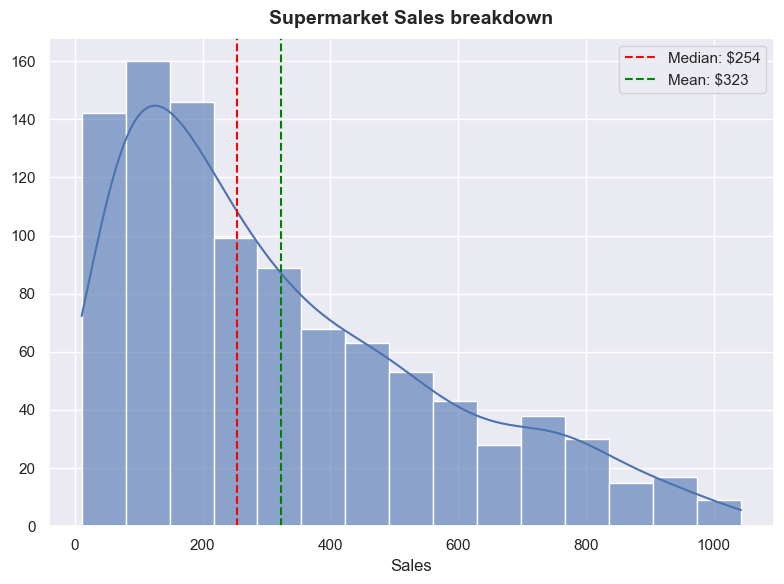

In [ ]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

sns.histplot(df_S, x='Sales', kde=True, alpha=0.6)

plt.title('Supermarket Sales breakdown', pad=10, fontsize=14, fontweight='bold')
plt.ylabel('')

median_price = df_S.Sales.median()
mean_price = df_S.Sales.mean()
plt.axvline(median_price, color='red', linestyle='--', linewidth=1.5, label=f'Median: ${median_price:,.0f}')
plt.axvline(mean_price, color='green', linestyle='--', label=f'Mean: ${mean_price:,.0f}')

plt.legend()
plt.tight_layout()
plt.show()

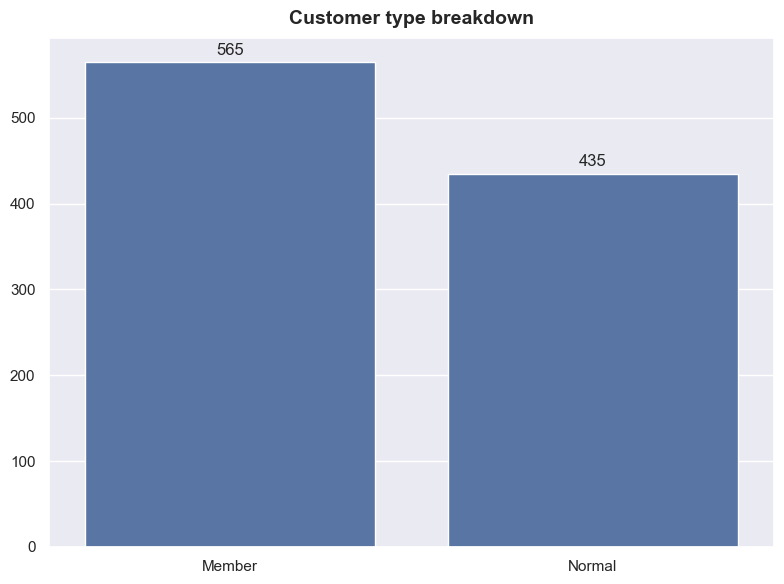

In [ ]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

ax = sns.countplot(df_S, x='Customer type')

plt.title('Customer type breakdown', pad=10, fontsize=14, fontweight='bold')
plt.ylabel('')
plt.xlabel('')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

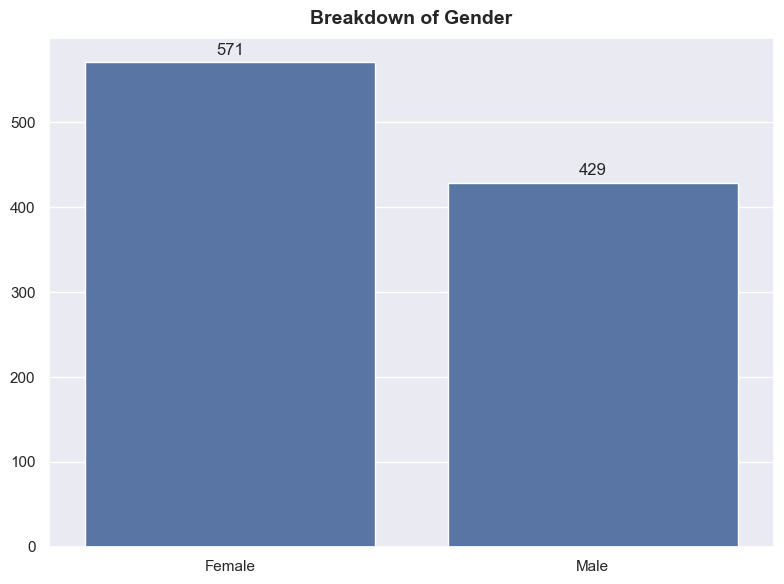

In [ ]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

ax = sns.countplot(df_S, x='Gender')

plt.title('Breakdown of Gender', pad=10, fontsize=14, fontweight='bold')
plt.ylabel('')
plt.xlabel('')


for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

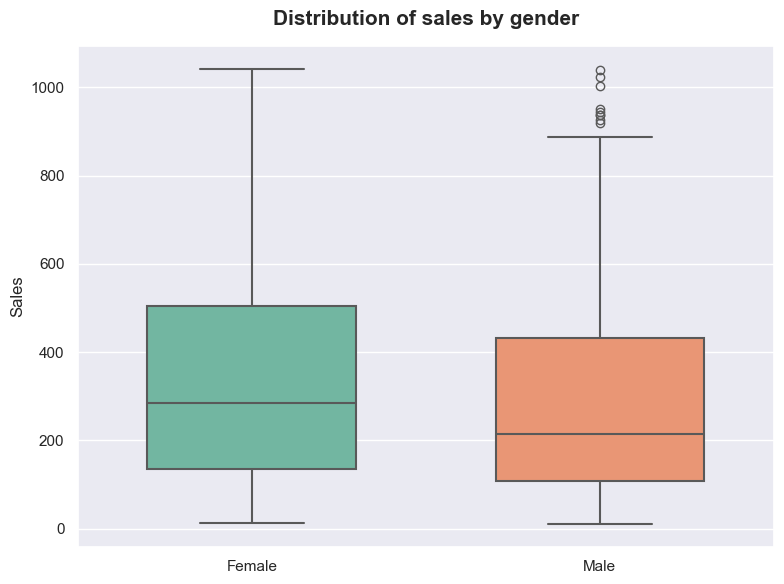

In [ ]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

sns.boxplot(data=df_S, x='Gender', y='Sales', hue='Gender', legend=False, palette='Set2', linewidth=1.5, width=0.6)

plt.title('Distribution of sales by gender', pad=15, fontsize=15, fontweight = 'bold')
plt.ylabel('Sales')
plt.xlabel('')

plt.tight_layout()
plt.show()

  Customer type       Sales
0        Member  189694.764
1        Normal  133271.985


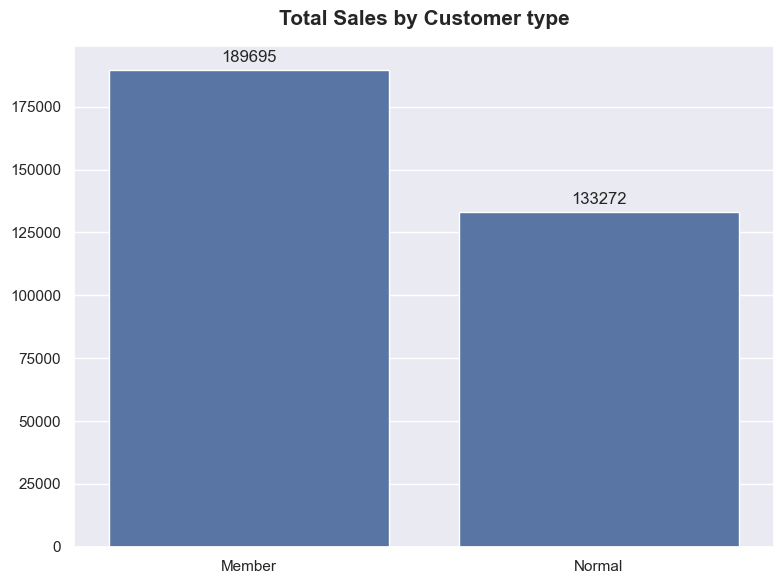

In [24]:
cust_sales = df_S.groupby('Customer type')['Sales'].sum().reset_index()
print(cust_sales)

sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=cust_sales, x=cust_sales['Customer type'], y=cust_sales['Sales'])

plt.title('Total Sales by Customer type', pad=15, fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('')

# Getting labels on each respective bars
for container in ax.containers:
    ax.bar_label(container, padding=3.5)

plt.tight_layout()
plt.show()

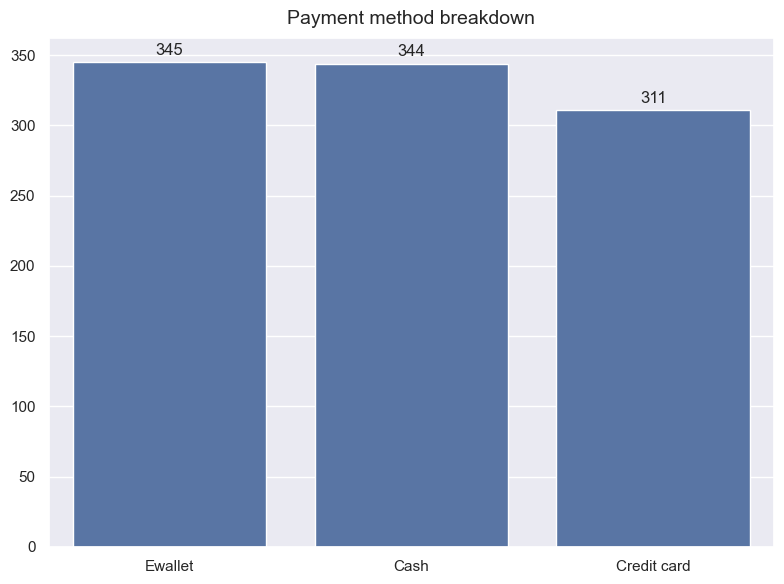

In [ ]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

ax = sns.countplot(df_S, x='Payment')

plt.title('Payment method breakdown', pad=10, fontsize=14)
plt.ylabel('')
plt.xlabel('')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

Prepping Dataset for modelling

In [ ]:
df_SL = df_S.copy()

df_SL.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,Payment,cogs,gross margin percentage,gross income,Rating,Datetime,Parsed_Date,Parsed_Time,Expected_Sales,Sales_Match
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,Ewallet,522.83,4.761905,26.1415,9.1,2019-01-05 13:08:00,2019-01-05,13:08:00,548.9715,True
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,Cash,76.40,4.761905,3.8200,9.6,2019-03-08 10:29:00,2019-03-08,10:29:00,80.2200,True
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,Credit card,324.31,4.761905,16.2155,7.4,2019-03-03 13:23:00,2019-03-03,13:23:00,340.5255,True
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,Ewallet,465.76,4.761905,23.2880,8.4,2019-01-27 20:33:00,2019-01-27,20:33:00,489.0480,True
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,Ewallet,604.17,4.761905,30.2085,5.3,2019-02-08 10:37:00,2019-02-08,10:37:00,634.3785,True


In [ ]:
# Dropping not so important columns or columns that are related

col_drop = [
        'Invoice ID', 'City', 'Tax 5%', 'Date','Time', 'cogs', 'gross margin percentage', 
        'gross income', 'Expected_Sales', 'Sales_Match', 'Parsed_Date',
        'Parsed_Time', 'Rating'
       ]

df_SL = df_SL.drop(col_drop, axis=1)

In [ ]:
df_SL.columns

Index(['Branch', 'Customer type', 'Gender', 'Product line', 'Unit price',
       'Quantity', 'Sales', 'Payment', 'Datetime'],
      dtype='object')

Extracting Hours, Day of week, month and Weekends from the Datetime column

In [ ]:
df_SL['Hour'] = df_SL['Datetime'].dt.hour
df_SL['Day_of_Week'] = df_SL['Datetime'].dt.day_of_week
df_SL['Month'] = df_SL['Datetime'].dt.month
df_SL['Is_Weekend'] = (df_SL.Day_of_Week > 5).astype(int)

In [ ]:
df_SL.head()

,Branch,Customer type,Gender,Product line,Unit price,Quantity,Sales,Payment,Datetime,Hour,Day_of_Week,Month,Is_Weekend
0,Alex,Member,Female,Health and beauty,74.69,7,548.9715,Ewallet,2019-01-05 13:08:00,13,5,1,0
1,Giza,Normal,Female,Electronic accessories,15.28,5,80.2200,Cash,2019-03-08 10:29:00,10,4,3,0
2,Alex,Normal,Female,Home and lifestyle,46.33,7,340.5255,Credit card,2019-03-03 13:23:00,13,6,3,1
3,Alex,Member,Female,Health and beauty,58.22,8,489.0480,Ewallet,2019-01-27 20:33:00,20,6,1,1
4,Alex,Member,Female,Sports and travel,86.31,7,634.3785,Ewallet,2019-02-08 10:37:00,10,4,2,0


In [ ]:
df_SL = df_SL.drop(columns=('Datetime'), axis=1)

In [ ]:
df_SL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Branch         1000 non-null   object 
 1   Customer type  1000 non-null   object 
 2   Gender         1000 non-null   object 
 3   Product line   1000 non-null   object 
 4   Unit price     1000 non-null   float64
 5   Quantity       1000 non-null   int64  
 6   Sales          1000 non-null   float64
 7   Payment        1000 non-null   object 
 8   Hour           1000 non-null   int32  
 9   Day_of_Week    1000 non-null   int32  
 10  Month          1000 non-null   int32  
 11  Is_Weekend     1000 non-null   int32  
dtypes: float64(2), int32(4), int64(1), object(5)
memory usage: 78.3+ KB


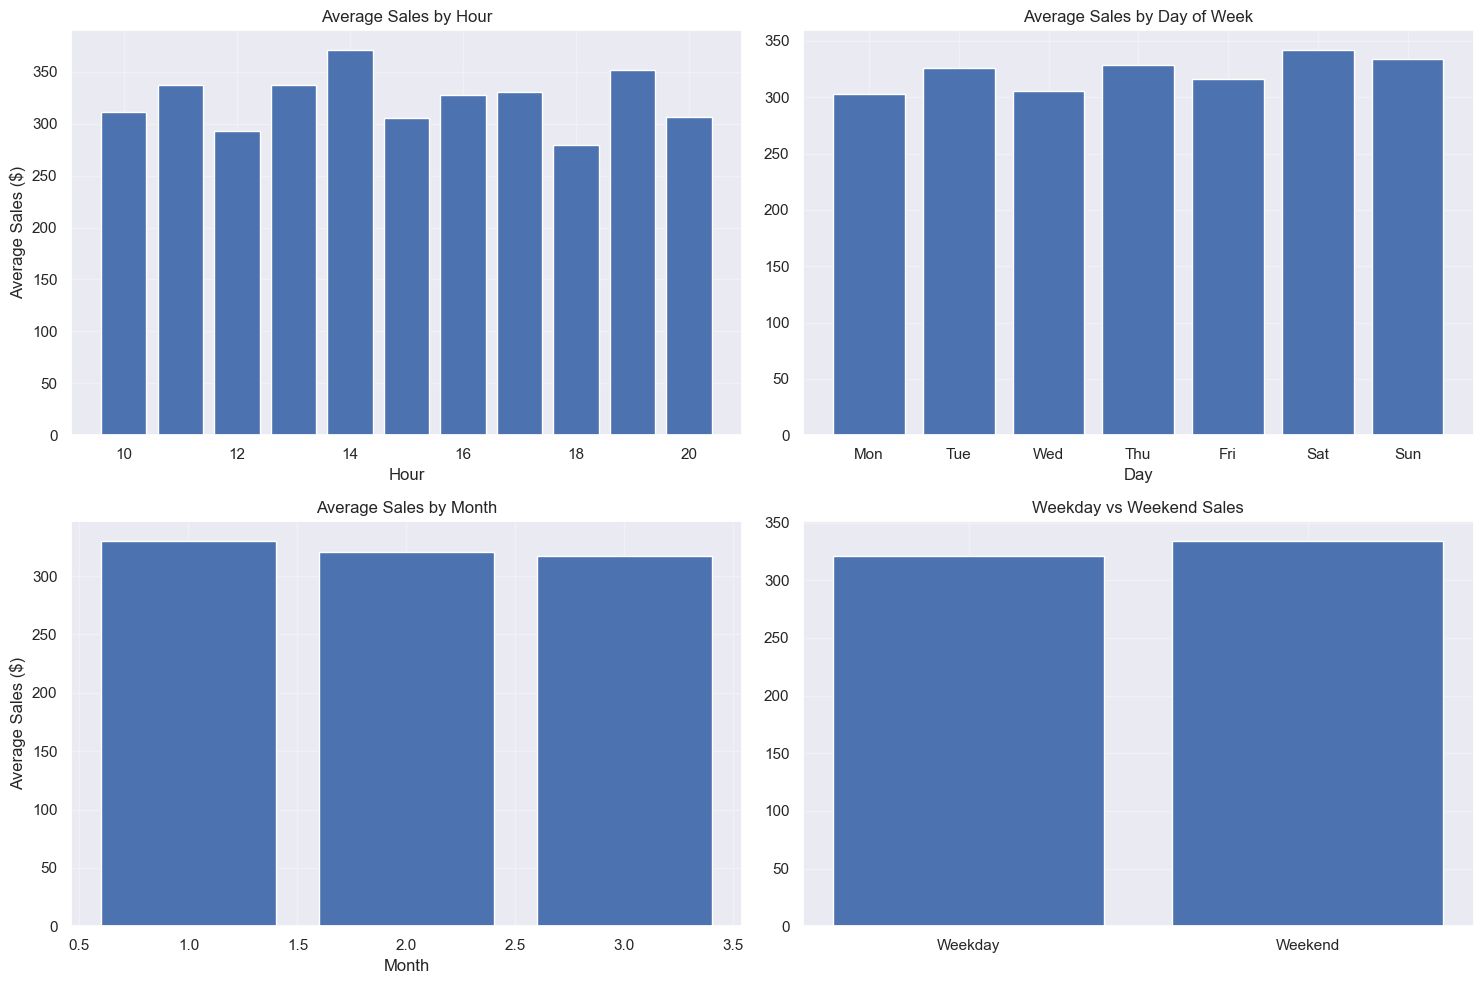


=== Time Feature Summary ===
Peak sales hour: 14 (371.43)
Highest sales day: Sat (342.20)
Weekend vs Weekday difference: $13.04


In [ ]:
# Creating a comprehensive time analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Sales by Hour
hourly_sales = df_SL.groupby('Hour')['Sales'].mean()
axes[0, 0].bar(hourly_sales.index, hourly_sales.values)
axes[0, 0].set_title('Average Sales by Hour')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Average Sales ($)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Sales by Day of Week
dow_sales = df_SL.groupby('Day_of_Week')['Sales'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[0, 1].bar(days, dow_sales.values)
axes[0, 1].set_title('Average Sales by Day of Week')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sales by Month
month_sales = df_SL.groupby('Month')['Sales'].mean()
axes[1, 0].bar(month_sales.index, month_sales.values)
axes[1, 0].set_title('Average Sales by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Sales ($)')
axes[1, 0].grid(True, alpha=0.3)


# 5. Weekend vs Weekday
weekend_sales = df_SL.groupby('Is_Weekend')['Sales'].mean()
axes[1, 1].bar(['Weekday', 'Weekend'], weekend_sales.values)
axes[1, 1].set_title('Weekday vs Weekend Sales')
axes[1, 1].set_ylabel('')
axes[1, 1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Summary statistics
print("\n=== Time Feature Summary ===")
print(f"Peak sales hour: {hourly_sales.idxmax()} ({hourly_sales.max():.2f})")
print(f"Highest sales day: {days[dow_sales.idxmax()]} ({dow_sales.max():.2f})")
print(f"Weekend vs Weekday difference: ${weekend_sales[1] - weekend_sales[0]:.2f}")

Handling Outliers

In [ ]:
import numpy as np

df_SL['Sales_Log'] = np.log1p(df_SL['Sales'])

df_SL.head()

,Branch,Customer type,Gender,Product line,Unit price,Quantity,Sales,Payment,Hour,Day_of_Week,Month,Is_Weekend,Sales_Log
0,Alex,Member,Female,Health and beauty,74.69,7,548.9715,Ewallet,13,5,1,0,6.309866
1,Giza,Normal,Female,Electronic accessories,15.28,5,80.2200,Cash,10,4,3,0,4.397162
2,Alex,Normal,Female,Home and lifestyle,46.33,7,340.5255,Credit card,13,6,3,1,5.833422
3,Alex,Member,Female,Health and beauty,58.22,8,489.0480,Ewallet,20,6,1,1,6.194503
4,Alex,Member,Female,Sports and travel,86.31,7,634.3785,Ewallet,10,4,2,0,6.454221


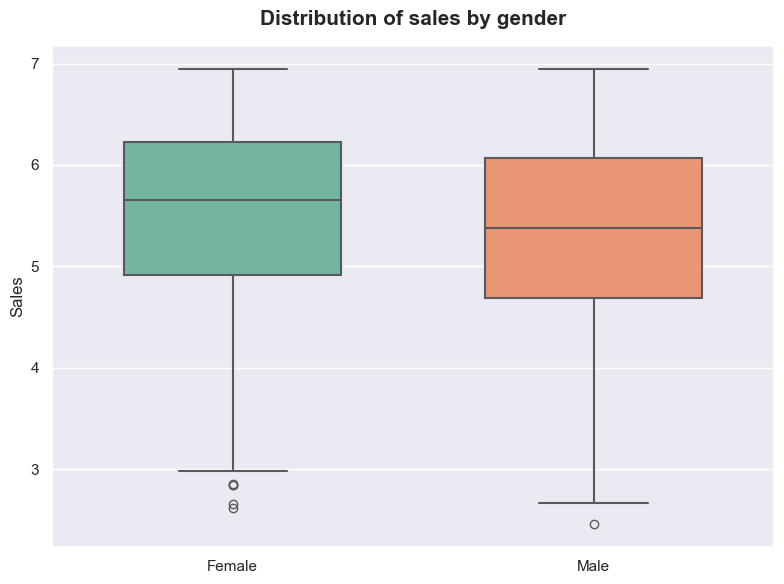

In [ ]:
sns.set_theme(style='darkgrid')
plt.figure(figsize=(8, 6))

sns.boxplot(data=df_SL, x='Gender', y='Sales_Log', hue='Gender', legend=False, palette='Set2', linewidth=1.5, width=0.6)

plt.title('Distribution of sales by gender', pad=15, fontsize=15, fontweight = 'bold')
plt.ylabel('Sales')
plt.xlabel('')

plt.tight_layout()
plt.show()

Feature Engineering / Transforming categorical variables

In [ ]:
df_SL1 = df_SL.copy()

In [ ]:
# Splitiing the dataset into X and y buckets

X = df_SL1.drop(columns=['Sales', 'Sales_Log'])
y = df_SL1['Sales_Log']

In [ ]:
X

,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Hour,Day_of_Week,Month,Is_Weekend
0,Alex,Member,Female,Health and beauty,74.69,7,Ewallet,13,5,1,0
1,Giza,Normal,Female,Electronic accessories,15.28,5,Cash,10,4,3,0
2,Alex,Normal,Female,Home and lifestyle,46.33,7,Credit card,13,6,3,1
3,Alex,Member,Female,Health and beauty,58.22,8,Ewallet,20,6,1,1
4,Alex,Member,Female,Sports and travel,86.31,7,Ewallet,10,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...
995,Giza,Normal,Male,Health and beauty,40.35,1,Ewallet,13,1,1,0
996,Cairo,Normal,Female,Home and lifestyle,97.38,10,Ewallet,17,5,3,0
997,Alex,Member,Male,Food and beverages,31.84,1,Cash,13,5,2,0
998,Alex,Normal,Male,Home and lifestyle,65.82,1,Cash,15,4,2,0


In [ ]:
y

0      6.309866
1      4.397162
2      5.833422
3      6.194503
4      6.454221
         ...   
995    3.769710
996    6.930974
997    3.538986
998    4.250080
999    6.477432
Name: Sales_Log, Length: 1000, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,Branch,Customer type,Gender,Product line,Unit price,Quantity,Payment,Hour,Day_of_Week,Month,Is_Weekend
29,Alex,Member,Female,Health and beauty,24.89,9,Cash,15,4,3,0
535,Giza,Normal,Male,Home and lifestyle,16.67,7,Ewallet,11,3,2,0
695,Alex,Member,Female,Home and lifestyle,87.37,5,Cash,19,1,1,0
557,Giza,Member,Female,Food and beverages,98.52,10,Ewallet,20,2,1,0
836,Alex,Member,Male,Fashion accessories,38.54,5,Ewallet,13,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...
106,Giza,Member,Female,Fashion accessories,27.38,6,Credit card,20,5,1,0
270,Cairo,Normal,Female,Sports and travel,67.43,5,Ewallet,18,2,3,0
860,Giza,Member,Female,Home and lifestyle,86.27,1,Ewallet,13,2,2,0
435,Giza,Normal,Male,Sports and travel,99.24,9,Ewallet,19,1,3,0


In [ ]:
# Catogorical and Numerical values classification

categorical_cols = ['Branch', 'Customer type', 'Gender', 'Product line', 'Payment']
numerical_cols = ['Unit price', 'Quantity', 'Hour', 'Day_of_Week', 'Month', 'Is_Weekend']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

In [ ]:
X_train

array([[-1.16030757,  1.18465655,  0.02765902, ...,  0.        ,
         0.        ,  0.        ],
       [-1.4733009 ,  0.5074681 , -1.21894463, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.21874632, -0.16972036,  1.27426267, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.17686157, -1.52409727, -0.59564281, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.67072087,  1.18465655,  1.27426267, ...,  1.        ,
         0.        ,  1.        ],
       [-1.2296078 ,  1.18465655, -1.21894463, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
X_test

array([[ 1.05882272,  0.16887387, -1.21894463, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.12936201,  1.52325078, -0.28399189, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.00941931,  0.5074681 , -0.90729372, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.95164536, -0.84690881, -0.59564281, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.97353014, -1.52409727,  0.33930993, ...,  1.        ,
         1.        ,  0.        ],
       [ 0.87376828,  1.52325078,  0.33930993, ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
print(f"X_train type: {type(X_train)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_train dtype: {X_train.dtype}")
print(f"y_train type: {type(y_train)}")
print(f"y_train shape: {y_train.shape}")

X_train type: <class 'numpy.ndarray'>
X_train shape: (800, 17)
X_train dtype: float64
y_train type: <class 'pandas.core.series.Series'>
y_train shape: (800,)


In [ ]:
print(f"X_test type: {type(X_test)}")
print(f"X_test shape: {X_test.shape}")
print(f"X_test dtype: {X_test.dtype}")
print(f"y_test type: {type(y_test)}")
print(f"y_test shape: {y_test.shape}")

X_test type: <class 'numpy.ndarray'>
X_test shape: (200, 17)
X_test dtype: float64
y_test type: <class 'pandas.core.series.Series'>
y_test shape: (200,)


Modelling

In [ ]:
# Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)


print("Linear Regression Performance:")
print(f"  R²: {lr.score(X_test, y_test):.4f}")
print(f"  Coefficients: {lr.coef_[:5]}")  # Interpretable!

Linear Regression Performance:
  R²: 0.9145
  Coefficients: [ 5.60301573e-01  6.76167650e-01  4.38269997e-04 -1.04051721e-02
  1.09639096e-02]


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
linear_preds = linear_model.predict(X_test)
linear_preds

array([6.10420273, 6.50898588, 5.74709076, 4.61307648, 3.90760374,
       6.51888337, 4.76049951, 6.73481144, 6.07500279, 4.70521274,
       6.19064904, 5.98563046, 5.27455187, 5.41585897, 5.6578003 ,
       5.82103185, 6.34491611, 5.1180943 , 6.82716584, 4.82146829,
       5.77496697, 5.28034799, 4.69815648, 4.68169757, 5.61931507,
       5.46390239, 6.61406792, 3.81358917, 4.75860035, 4.3369722 ,
       4.75263059, 6.38801895, 5.20891642, 5.88283533, 5.1303151 ,
       4.79261089, 6.61993651, 5.01011887, 4.91108403, 4.98052413,
       4.98027192, 7.17356609, 4.46536114, 5.18374198, 5.03313809,
       5.85471403, 5.07356451, 4.50034993, 5.67161334, 5.31568182,
       5.91436268, 5.06416437, 4.19385365, 5.31427874, 4.9055652 ,
       6.10457274, 5.97967988, 4.17028993, 5.99069441, 5.09018757,
       4.48583676, 3.82305666, 4.33036934, 7.20791393, 5.57814157,
       6.33215172, 5.60055731, 6.74499023, 7.18442882, 4.71828251,
       5.67044317, 5.52633812, 5.3482327 , 5.03883396, 4.55644

In [ ]:
# Ridge Regression Model
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [ ]:
ridge_preds = ridge_model.predict(X_test)
ridge_preds

array([6.10365786, 6.50735742, 5.74682463, 4.61443187, 3.90970084,
       6.51762583, 4.76119182, 6.73254056, 6.07393205, 4.70557685,
       6.18909547, 5.98533236, 5.27439962, 5.41545773, 5.65759892,
       5.82015708, 6.34338176, 5.1184039 , 6.82495262, 4.82247383,
       5.77406328, 5.28026618, 4.69920877, 4.68294559, 5.61849399,
       5.46380725, 6.61311911, 3.81565703, 4.75928782, 4.33862806,
       4.75302317, 6.38672043, 5.20886004, 5.88249586, 5.13075558,
       4.79339576, 6.61827659, 5.01081657, 4.91167276, 4.98116196,
       4.98099259, 7.17158595, 4.46622585, 5.18432926, 5.03409911,
       5.85450912, 5.07451526, 4.50184392, 5.67111157, 5.31583424,
       5.91370638, 5.06464481, 4.19572096, 5.31422826, 4.90591482,
       6.10385256, 5.97888731, 4.17221139, 5.98956835, 5.09012744,
       4.48692121, 3.82523965, 4.33204702, 7.2052926 , 5.57849054,
       6.33087142, 5.60059541, 6.74348463, 7.18224792, 4.719033  ,
       5.67030581, 5.5263735 , 5.34859281, 5.03905895, 4.55718

In [ ]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rfr_preds = rfr.predict(X_test)
rfr_preds

array([6.27107002, 6.37704445, 6.01920678, 4.88628996, 3.93003315,
       6.3883072 , 4.83025465, 6.56946485, 6.12425027, 4.95104855,
       6.03930586, 6.17612028, 5.38695697, 5.53232457, 5.68848628,
       5.84090231, 6.38899446, 5.40943472, 6.61234001, 5.23791971,
       6.00561271, 5.17734624, 4.83473649, 4.8072567 , 5.46552246,
       5.28111993, 6.61216016, 3.48913644, 4.98118285, 4.05103438,
       4.33869013, 6.42131573, 4.57429602, 6.07228577, 5.26957771,
       5.18553198, 6.47900413, 5.31517701, 5.27713328, 5.26543379,
       5.39335588, 6.81372689, 4.26054613, 5.20868923, 4.53146445,
       5.99529573, 5.427154  , 4.22856915, 5.76120338, 5.66311307,
       6.07927883, 4.60930661, 4.3386252 , 5.59584895, 5.21991682,
       6.19407671, 6.14133624, 4.26012266, 6.12870132, 5.42531569,
       4.84925504, 3.75423658, 4.49816114, 6.83293462, 5.96217711,
       6.186002  , 5.91853453, 6.6327767 , 6.83766477, 4.79049941,
       5.96848556, 4.74943383, 5.68010031, 4.51059678, 4.18920

In [ ]:
#xgboost
from xgboost import XGBRegressor

xgt = XGBRegressor(n_estimators=100, random_state=42)
xgt.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgt_preds = xgt.predict(X_test)
xgt_preds

array([6.2606335, 6.4058623, 6.0148845, 4.9667106, 3.7329562, 6.409848 ,
       4.899425 , 6.5958886, 6.149457 , 4.9444947, 6.0130124, 6.157017 ,
       5.3953886, 5.5452766, 5.6946983, 5.8274784, 6.388601 , 5.4009113,
       6.6274447, 5.268072 , 5.9711366, 5.139574 , 4.9022794, 4.8079276,
       5.493937 , 5.285139 , 6.6016097, 3.4313695, 4.9728866, 4.0414524,
       4.3854733, 6.411457 , 4.574146 , 6.070507 , 5.24405  , 5.2017694,
       6.4962397, 5.2711644, 5.273648 , 5.258317 , 5.3649635, 6.8087697,
       4.2229304, 5.205723 , 4.5408735, 5.9922338, 5.4179106, 4.2600384,
       5.7827687, 5.658934 , 6.030395 , 4.647664 , 4.3202844, 5.627545 ,
       5.2346225, 6.2034388, 6.1519914, 4.186681 , 6.1362906, 5.4633045,
       4.8868027, 3.512274 , 4.499714 , 6.8483033, 5.96506  , 6.2510195,
       5.962984 , 6.6451964, 6.8499217, 4.8445435, 5.9706397, 4.7705827,
       5.686005 , 4.5216556, 4.258051 , 6.550141 , 6.631335 , 5.495711 ,
       4.3807526, 6.643118 , 5.724023 , 4.2858205, 

In [ ]:
metrics = {
    "Mean Absolute Error": mean_absolute_error,
    "Mean Squared Error": mean_squared_error,
    'r2': r2_score
}

results = {}
for name, func in metrics.items():
    # Calculate scores for each model
    linear_score = func(y_test, linear_preds)
    ridge_score = func(y_test, ridge_preds)
    rfr_score = func(y_test, rfr_preds)
    xgt_score = func(y_test, xgt_preds)

    # Store results in the dictionary
    results[name] = {
        "Linear Regression": linear_score,
        "Ridge": ridge_score,
        "Random Forest Regressor": rfr_score,
        "Xgboost": xgt_score
    }

results

{'Mean Absolute Error': {'Linear Regression': 0.22897360336135528,
  'Ridge': 0.22878248964495423,
  'Random Forest Regressor': 0.02288999286380525,
  'Xgboost': 0.025462450234336406},
 'Mean Squared Error': {'Linear Regression': 0.07435247936261898,
  'Ridge': 0.0743205637170407,
  'Random Forest Regressor': 0.0015809330926232629,
  'Xgboost': 0.0018622447045271156},
 'r2': {'Linear Regression': 0.9145335719255969,
  'Ridge': 0.9145702582103133,
  'Random Forest Regressor': 0.9981827545549333,
  'Xgboost': 0.997859393466623}}

In [ ]:
def create_model_comparison_table(y_test, predictions_dict, model_names):
 
    # Initializing results list
    results_list = []
    
    # Calculate metrics for each model
    for model_name in model_names:
        y_pred = predictions_dict[model_name]
        
        # Calculate metrics (assuming y_test and y_pred are on log scale)
        r2 = r2_score(y_test, y_pred)
        rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Converting back to original scale for business metrics
        y_test_orig = np.expm1(y_test)
        y_pred_orig = np.expm1(y_pred)
        
        mae = mean_absolute_error(y_test_orig, y_pred_orig)
        mape = np.mean(np.abs((y_test_orig - y_pred_orig) / y_test_orig)) * 100
        
        results_list.append({
            'Model': model_name,
            'R²': r2,
            'RMSE (log)': rmse_log,
            'MAE ($)': mae,
            'MAPE (%)': mape
        })
    
    # Create DataFrame and sort by R²
    results_df = pd.DataFrame(results_list)
    results_df = results_df.sort_values('R²', ascending=False)
    
    return results_df

# Predictions (from the trained models)
predictions_dict = {
    'Linear Regression': linear_preds,
    'Ridge': ridge_preds,
    'Random Forest': rfr_preds,
    'XGBoost': xgt_preds
}

model_names = ['Linear Regression', 'Ridge', 'Random Forest', 'XGBoost']

# Creating the formatted table
results_df = create_model_comparison_table(y_test, predictions_dict, model_names)

print("="*65)
print("MODEL PERFORMANCE COMPARISON")
print("="*65)
print(results_df.round(4).to_string(index=False))

# Get best model
best_model = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R²']
best_mae = results_df.iloc[0]['MAE ($)']

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   R²: {best_r2:.4f}")
print(f"   MAE: ${best_mae:.2f}")

MODEL PERFORMANCE COMPARISON
            Model     R²  RMSE (log)  MAE ($)  MAPE (%)
    Random Forest 0.9982      0.0398   5.2401    2.3612
          XGBoost 0.9979      0.0432   5.7099    2.6453
            Ridge 0.9146      0.2726  66.4437   24.2343
Linear Regression 0.9145      0.2727  66.7239   24.2469

🏆 BEST MODEL: Random Forest
   R²: 0.9982
   MAE: $5.24


In [ ]:
results_df

,Model,R²,RMSE (log),MAE ($),MAPE (%)
2,Random Forest,0.998183,0.039761,5.240054,2.361184
3,XGBoost,0.997859,0.043154,5.709904,2.645327
1,Ridge,0.914570,0.272618,66.443652,24.234344
0,Linear Regression,0.914534,0.272677,66.723894,24.246893


## 4. Provide actionable insights that could support business decision-making.